# 高频收益预测
- 基于高频数据中002507这只股票的snapshot数据，参考《Modeling high frequency limit order book dynamics with support vector machines》

- 首先导入需要的 python 库

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import lightgbm as lgb
import xgboost as xgb
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')
import random
random.seed(42)
np.random.seed(42)

In [2]:
# 查看列名
_df = pd.read_parquet("002507/2019-05-14.parquet")
_df.columns

Index(['symbol', 'date', 'time', 'last', 'pre_close', 'open', 'high', 'low',
       'volume', 'turnover', 'acc_volume', 'acc_turnover', 'match_items',
       'total_ask_qty', 'total_bid_qty', 'wavg_ask', 'wavg_bid', 'interest',
       'ask_price1', 'ask_volume1', 'bid_price1', 'bid_volume1', 'ask_price2',
       'ask_volume2', 'bid_price2', 'bid_volume2', 'ask_price3', 'ask_volume3',
       'bid_price3', 'bid_volume3', 'ask_price4', 'ask_volume4', 'bid_price4',
       'bid_volume4', 'ask_price5', 'ask_volume5', 'bid_price5', 'bid_volume5',
       'ask_price6', 'ask_volume6', 'bid_price6', 'bid_volume6', 'ask_price7',
       'ask_volume7', 'bid_price7', 'bid_volume7', 'ask_price8', 'ask_volume8',
       'bid_price8', 'bid_volume8', 'ask_price9', 'ask_volume9', 'bid_price9',
       'bid_volume9', 'ask_price10', 'ask_volume10', 'bid_price10',
       'bid_volume10'],
      dtype='object')

### 数据预处理

- preprocess: 数据预处理函数

In [3]:
def preprocess(df):
    # 合并日期和时间
    df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
    df = df.sort_values('datetime').reset_index(drop=True)
    
    # 提取时间用于过滤
    df['time_str'] = df['datetime'].dt.time.astype(str)
    
    # 仅保留 09:30:00 - 11:30:00 和 13:00:00 - 14:57:00的数据
    mask = (
        ((df['time_str'] >= '09:30:00') & (df['time_str'] <= '11:30:00')) |
        ((df['time_str'] >= '13:00:00') & (df['time_str'] <= '14:57:00'))
    )
    df = df[mask].copy()
    return df.reset_index(drop=True)

- features: 构建特征

In [ ]:
def features(df):
    """
    构建特征
    """
    
    # 20 ticks ≈ 1分钟, 60 ticks ≈ 3分钟, 100 ticks ≈ 5分钟
    windows_long = [20, 60, 100] 
    
    # 基础价格定义
    df['mid_price'] = (df['ask_price1'] + df['bid_price1']) / 2
    ask_prices = [f'ask_price{i}' for i in range(1, 11)]
    bid_prices = [f'bid_price{i}' for i in range(1, 11)]
    ask_cols = [f'ask_volume{i}' for i in range(1, 11)]
    bid_cols = [f'bid_volume{i}' for i in range(1, 11)]
    sum_ask_vol = df[ask_cols].sum(axis=1)
    sum_bid_vol = df[bid_cols].sum(axis=1)
    
    
    
    # Set v2: Spreads & Mid-Prices 
    for i in range(1, 11):
        df[f'spread_{i}'] = df[f'ask_price{i}'] - df[f'bid_price{i}']
        df[f'mid_price_{i}'] = (df[f'ask_price{i}'] + df[f'bid_price{i}']) / 2
        df[f'rel_spread_{i}'] = df[f'spread_{i}'] / df[f'mid_price_{i}'] # 相对价差

    df = df[df['mid_price_1'] > 0]
    df = df.fillna(method='ffill').dropna()


    # Set v3: Price Differences 
    for i in range(1, 10):
        df[f'ask_diff_{i}_{i+1}'] = abs(df[f'ask_price{i+1}'] - df[f'ask_price{i}']) # 相对价差
        df[f'bid_diff_{i}_{i+1}'] = abs(df[f'bid_price{i+1}'] - df[f'bid_price{i}'])
    
    # P_n_ask - P_1_ask 和 P_1_bid - P_n_bid
    df['ask_price_range_10_1'] = df['ask_price10'] - df['ask_price1']
    df['bid_price_range_1_10'] = df['bid_price1'] - df['bid_price10']

    # Set v4: Mean Prices & Volumes 
    df['mean_ask_price'] = df[ask_prices].mean(axis=1)
    df['mean_bid_price'] = df[bid_prices].mean(axis=1)
    df['mean_ask_vol'] = df[ask_cols].mean(axis=1)
    df['mean_bid_vol'] = df[bid_cols].mean(axis=1)

    # Set v5: Accumulated Differences
    sum_ask_vol = df[ask_cols].sum(axis=1)
    sum_bid_vol = df[bid_cols].sum(axis=1)
    df['vol_diff'] = sum_ask_vol - sum_bid_vol
    
    total_ask_price = df[ask_prices].sum(axis=1)
    total_bid_price = df[bid_prices].sum(axis=1)
    df['price_diff'] = total_ask_price - total_bid_price


    df['time'] = pd.to_datetime(df['time']) 
    df['real_dt'] = df['time'].diff().dt.total_seconds()
    df['real_dt'] = df['real_dt'].replace(0, np.nan).fillna(3.0)
    
    # Set v6: Derivatives 
    for col in ask_prices + bid_prices + ask_cols + bid_cols:
        df[f'deriv_{col}'] = df[col].diff() / df['real_dt']

    # Set v7, v8, v9: Intensities 
    df['lambda_market'] = df['volume'] / df['real_dt']  # 成交强度
    df['lambda_ask_flow'] = sum_ask_vol.diff() / df['real_dt'] # 卖单流强度
    df['lambda_bid_flow'] = sum_bid_vol.diff() / df['real_dt'] # 买单流强度
    
    # 相对强度 (Indicator)
    window_long = 300 
    for metric in ['lambda_market', 'lambda_ask_flow', 'lambda_bid_flow']:
        long_avg = df[metric].rolling(window=window_long).mean()
        df[f'{metric}_rel_indicator'] = (df[metric] > long_avg).astype(int)

    # 加速度 (Acceleration)
    for metric in ['lambda_market', 'lambda_ask_flow', 'lambda_bid_flow']:
        df[f'accel_{metric}'] = df[metric].diff() / df['real_dt']
        
    df['lambda_ask_activity'] = df['lambda_ask_flow'].abs() # 活跃度
    df['lambda_bid_activity'] = df['lambda_bid_flow'].abs()
    
    
    # Depth Imbalance (盘口不平衡)
    for i in [1, 5, 10]:
        ask_sum_i = df[[f'ask_volume{j}' for j in range(1, i+1)]].sum(axis=1)
        bid_sum_i = df[[f'bid_volume{j}' for j in range(1, i+1)]].sum(axis=1)
        df[f'vol_imbalance_{i}'] = (bid_sum_i - ask_sum_i) / (bid_sum_i + ask_sum_i + 1e-6)

    # Micro-Price & Deviation
    df['micro_price'] = (df['ask_price1'] * df['bid_volume1'] + df['bid_price1'] * df['ask_volume1']) / \
                        (df['bid_volume1'] + df['ask_volume1'] + 1e-6)
    df['micro_price_dev'] = df['micro_price'] - df['mid_price']

    # RSI (相对强弱指标) 
    delta = df['mid_price'].diff()
    up = delta.clip(lower=0)
    down = -1 * delta.clip(upper=0)
    ema_up = up.ewm(com=13, adjust=False).mean()
    ema_down = down.ewm(com=13, adjust=False).mean()
    rs = ema_up / (ema_down + 1e-6)
    df['RSI_14t'] = 100 - (100 / (1 + rs))

    
    # 资金流 
    price_change = df['mid_price'].diff()
    raw_flow = np.where(price_change > 0, df['turnover'], 
               np.where(price_change < 0, -df['turnover'], 0))
    raw_flow_series = pd.Series(raw_flow)
    
    for w in windows_long:
        # 收益率
        df[f'ret_{w}'] = df['mid_price'].pct_change(w)
        
        # 均线乖离: 当前价格偏离 w 周期均线的程度
        ma_w = df['mid_price'].rolling(w).mean()
        df[f'ma_bias_{w}'] = df['mid_price'] / ma_w - 1
        
        # 过去 w 时间的标准差
        std_w = df['mid_price'].rolling(w).std()
        df[f'std_{w}'] = std_w
        
        # 机构成本分析 (VWAP)
        # 滚动成交额 / 滚动成交量 = 滚动 VWAP
        roll_turnover = df['turnover'].rolling(w).sum()
        roll_volume = df['volume'].rolling(w).sum()
        vwap_w = roll_turnover / (roll_volume + 1e-6)
        
        # 当前价格相对于 VWAP 的位置 (正数代表多头强势)
        df[f'price_rel_vwap_{w}'] = df['mid_price'] / vwap_w - 1
        
        # 累计净流入
        df[f'flow_sum_{w}'] = raw_flow_series.rolling(w).sum()
        
        # 资金流强度: 净流入占总成交的比例
        df[f'flow_ratio_{w}'] = df[f'flow_sum_{w}'] / (roll_turnover + 1e-6)
        
        # 区间位置
        high_w = df['mid_price'].rolling(w).max()
        low_w = df['mid_price'].rolling(w).min()
        df[f'pos_in_range_{w}'] = (df['mid_price'] - low_w) / (high_w - low_w + 1e-6)
        
        # 挂单意愿平滑 
        df[f'mean_imbalance_{w}'] = df['vol_imbalance_10'].rolling(w).mean()
        
        # Bollinger Band Position
        df[f'bb_pos_{w}'] = (df['mid_price'] - (ma_w - 2 * std_w)) / (4 * std_w + 1e-6)
        
        # 1-10档的总量比值
        sum_ask = df[ask_cols].sum(axis=1).rolling(w).mean() 
        sum_bid = df[bid_cols].sum(axis=1).rolling(w).mean()
        df[f'depth_ratio_{w}'] = sum_bid / (sum_ask + 1e-6)
        
        # Micro-price 是未来的预期价格
        df[f'micro_trend_{w}'] = df['micro_price'].pct_change(w) - df[f'ret_{w}']
    
    # MACD:趋势指标
    ema_12 = df['mid_price'].ewm(span=12, adjust=False).mean()
    ema_26 = df['mid_price'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']
    
    # 量价交互
    vol_change = np.log(df['volume'] + 1).diff()
    df['price_vol_interaction'] = df['mid_price'].diff() * vol_change
    
    # 买单流
    bid_p_change = df['bid_price1'].diff()
    bid_v_change = df['bid_volume1'].diff()
    ofi_bid = np.where(bid_p_change > 0, df['bid_volume1'], 
              np.where(bid_p_change == 0, bid_v_change, 
              -df['bid_volume1'].shift(1)))
    
    # 卖单流
    ask_p_change = df['ask_price1'].diff()
    ask_v_change = df['ask_volume1'].diff()
    ofi_ask = np.where(ask_p_change < 0, -df['ask_volume1'], 
              np.where(ask_p_change == 0, -ask_v_change, 
              df['ask_volume1'].shift(1)))
    
    df['raw_OFI'] = ofi_bid + ofi_ask
    
    # 对 OFI 进行平滑 (因为它波动极大)
    for w in windows_long:
        df[f'OFI_sum_{w}'] = df['raw_OFI'].rolling(w).sum()
    
    # 非流动性/价格冲击
    abs_ret = df['mid_price'].pct_change().abs()
    df['amihud_illiq'] = abs_ret / (df['turnover'] + 1e-6)
    
    # 平滑 Amihud
    for w in windows_long:
        df[f'amihud_mean_{w}'] = df['amihud_illiq'].rolling(w).mean()
    
    
    # 峰度/偏度
    ret_1tick = df['mid_price'].pct_change()

    for w in [60, 100]:
        # 偏度：正偏(>0)代表右尾长，往往暗示短期超买，需回调
        df[f'ret_skew_{w}'] = ret_1tick.rolling(w).skew()
        # 峰度：高峰度(>3)代表极端行情多，肥尾风险
        df[f'ret_kurt_{w}'] = ret_1tick.rolling(w).kurt()
    
    # 改进后的量价相关性
    for w in windows_long:
        df[f'corr_price_vol_{w}'] = df['mid_price'].rolling(w).corr(df['volume'])
    
    # 盘口斜率
    df['ask_slope'] = (df['ask_price10'] - df['ask_price1']) / (sum_ask_vol + 1e-6)
    df['bid_slope'] = (df['bid_price1'] - df['bid_price10']) / (sum_bid_vol + 1e-6)
    df['slope_diff'] = df['ask_slope'] - df['bid_slope']
    
    # 集中度
    df['ask_conc_L1'] = df['ask_volume1'] / (sum_ask_vol + 1e-6)
    df['bid_conc_L1'] = df['bid_volume1'] / (sum_bid_vol + 1e-6)
    
    # 压力的二阶导数
    for w in [20, 60]:
        df[f'OFI_acc_{w}'] = df[f'OFI_sum_{w}'].diff(5)
     
    # 典型价格   
    tp = (df['ask_price1'] + df['bid_price1'] + df['mid_price']) / 3
    # 原始资金流
    raw_money_flow = tp * df['volume']
    
    flow_pos = np.where(tp > tp.shift(1), raw_money_flow, 0)
    flow_neg = np.where(tp < tp.shift(1), raw_money_flow, 0)
    flow_pos_s = pd.Series(flow_pos)
    flow_neg_s = pd.Series(flow_neg)
    
    for w in [20, 60]:
        mf_pos = flow_pos_s.rolling(w).sum()
        mf_neg = flow_neg_s.rolling(w).sum()
        # MFI 公式
        mfi_ratio = mf_pos / (mf_neg + 1e-6)
        df[f'MFI_{w}'] = 100 - (100 / (1 + mfi_ratio))   
     
    # 波动率   
    for w in [20, 100]:
        df[f'std_ratio_{w}'] = df[f'std_{w}'] / (df[f'std_{w}'].rolling(w*2).mean() + 1e-9)
    df = df.dropna()

    return df

In [ ]:
# 根据 features() 函数实际生成的特征重新构建特征列
feature_cols = []

windows_long = [20, 60, 100]

# 原始价格和量数据 
for i in range(1, 3):
    feature_cols.extend([f'ask_price{i}', f'ask_volume{i}', f'bid_price{i}', f'bid_volume{i}'])

# Set v2: Spreads & Mid-Prices 
for i in range(1, 11):
    feature_cols.extend([f'spread_{i}', f'mid_price_{i}', f'rel_spread_{i}'])

# Set v3: Price Differences 
for i in range(1, 10):
    feature_cols.extend([f'ask_diff_{i}_{i+1}', f'bid_diff_{i}_{i+1}'])
feature_cols.extend(['ask_price_range_10_1', 'bid_price_range_1_10'])

# Set v4: Mean Prices & Volumes 
feature_cols.extend(['mean_ask_price', 'mean_bid_price', 'mean_ask_vol', 'mean_bid_vol'])

# Set v5: Accumulated Differences
feature_cols.extend(['vol_diff', 'price_diff'])

# Set v6: Derivatives 
for i in range(1, 11):
    feature_cols.extend([f'deriv_ask_price{i}', f'deriv_bid_price{i}', 
                         f'deriv_ask_volume{i}', f'deriv_bid_volume{i}'])

# Set v7, v8, v9: Intensities 
feature_cols.extend(['lambda_market', 'lambda_ask_flow', 'lambda_bid_flow'])
feature_cols.extend(['lambda_market_rel_indicator', 'lambda_ask_flow_rel_indicator', 'lambda_bid_flow_rel_indicator'])
feature_cols.extend(['accel_lambda_market', 'accel_lambda_ask_flow', 'accel_lambda_bid_flow'])
feature_cols.extend(['lambda_ask_activity', 'lambda_bid_activity'])



# 盘口不平衡特征
for i in [1, 5, 10]:
    feature_cols.append(f'vol_imbalance_{i}')

# 微观价格特征 
feature_cols.extend(['micro_price', 'micro_price_dev'])

# RSI 指标 
feature_cols.append('RSI_14t')

# 时间窗口特征 
for w in windows_long:
    feature_cols.extend([
        f'ret_{w}',            # 收益率
        f'ma_bias_{w}',        # 均线乖离
        f'std_{w}',            # 标准差
        f'price_rel_vwap_{w}', # 价格相对VWAP
        f'flow_sum_{w}',       # 累计净流入
        f'flow_ratio_{w}',     # 资金流强度
        f'pos_in_range_{w}',   # 区间位置
        f'mean_imbalance_{w}', # 平滑挂单意愿
        f'bb_pos_{w}',         # 布林带位置
        f'depth_ratio_{w}',    # 深度比值
        f'micro_trend_{w}',    # 微观趋势
    ])

# MACD 趋势指标 
feature_cols.extend(['MACD', 'MACD_signal', 'MACD_hist'])

# 量价交互 
feature_cols.append('price_vol_interaction')

# OFI 订单流不平衡 
feature_cols.append('raw_OFI')
for w in windows_long:
    feature_cols.append(f'OFI_sum_{w}')

# 非流动性/价格冲击 Amihud
feature_cols.append('amihud_illiq')
for w in windows_long:
    feature_cols.append(f'amihud_mean_{w}')

# 峰度/偏度 
for w in [60, 100]:
    feature_cols.extend([f'ret_skew_{w}', f'ret_kurt_{w}'])

# 量价相关性
for w in windows_long:
    feature_cols.append(f'corr_price_vol_{w}')

# 盘口斜率
feature_cols.extend(['ask_slope', 'bid_slope', 'slope_diff'])

# 集中度 
feature_cols.extend(['ask_conc_L1', 'bid_conc_L1'])

# OFI 加速度
for w in [20, 60]:
    feature_cols.append(f'OFI_acc_{w}')

# MFI 资金流指标
for w in [20, 60]:
    feature_cols.append(f'MFI_{w}')

# 波动率比率 
for w in [20, 100]:
    feature_cols.append(f'std_ratio_{w}')

print(f"特征总数: {len(feature_cols)}")

特征总数: 184


- get_dt: 估算时间间隔

In [6]:
def get_dt(df):
    """
    计算采样间隔 dt（中位数）
    """
    if not np.issubdtype(df['datetime'].dtype, np.datetime64):
        try:
             time_series = pd.to_datetime(df['datetime'])
        except:
             pass
    else:
        time_series = df['datetime']
    print(time_series.head())
    time_diff = time_series.diff().dt.total_seconds()
    valid_diffs = time_diff[(time_diff > 0) & (time_diff < 60)]

    if len(valid_diffs) > 0:
        dt = valid_diffs.median()
        print(f"dt: {dt} seconds")
    else:
        print("error!")

- process_one_day: 处理单日数据

In [7]:
def process_one_day(file_path):
    df = pd.read_parquet(file_path) # 读取单日数据
    df = preprocess(df) # 预处理
    df = features(df) # 构建特征
    return df

- process_all: 处理所有数据

In [30]:
def process_all(dir):
    """
    处理所有数据
    """
    
    file_list = sorted(glob.glob(os.path.join(dir, "*.parquet")))
    print(f"共 {len(file_list)} 个文件")
    
    processed_days = []
    for f in file_list:
        try:
            
            df = process_one_day(f)
            
            horizon = 5          # 预测未来15s
            threshold = 0.00008
            
            # horizon = 20          # 预测未来1min
            # threshold = 0.0003
            
            # horizon = 60 # 未来3分钟
            # threshold = 0.0005
            
            # horizon = 10 # 未来30s
            # threshold = 0.0002
            future_time = df['datetime'].shift(-horizon)
            time_delta = (future_time - df['datetime']).dt.total_seconds()
            valid_mask = (time_delta >= 5) & (time_delta <= 90)
            
            # 未来 horizon 时间内的平均中间价
            future_mean_price = df['mid_price'].rolling(horizon).mean().shift(-horizon)
            df['target_return'] = future_mean_price / df['mid_price'] - 1
            future_exact = df['mid_price'].shift(-horizon) 
            df['real_target_return'] = future_exact / df['mid_price'] - 1
            df['Label_mean'] = 0
            df.loc[df['target_return'] > threshold, 'Label_mean'] = 1
            df.loc[df['target_return'] < -threshold, 'Label_mean'] = -1
            df.loc[~valid_mask, 'Label_mean'] = np.nan
            
            
            # 未来 horizon 时间内中间价的最高和最低
            future_high = df['mid_price'].rolling(horizon).max().shift(-horizon)
            future_low = df['mid_price'].rolling(horizon).min().shift(-horizon)
            # 潜在最大涨幅和最大跌幅
            max_up = future_high / df['mid_price'] - 1
            max_down = future_low / df['mid_price'] - 1
            
            threshold = 0.0003 # 未来30s
            df['Label_diff'] = 0
            df.loc[(max_up > threshold) & (max_down > -threshold/2), 'Label_diff'] = 1
            df.loc[(max_down < -threshold) & (max_up < threshold/2), 'Label_diff'] = -1
            
            # 去除最后没有标签的 horizon 行
            df = df.dropna(subset=['Label_mean', 'Label_diff']) 
            
            # 保留 target_return 用于回测
            cols = ['datetime', 'real_target_return', 'Label_mean', 'Label_diff'] + feature_cols
            cols = [c for c in cols if c in df.columns]
            df = df[cols]
        
            for col in feature_cols:
                df[col] = df[col].astype(np.float32) # 节省内存
            df['Label_mean'] = df['Label_mean'].astype(np.int8)
            df['Label_diff'] = df['Label_diff'].astype(np.int8)
            processed_days.append(df)
            
        except Exception as e:
            print(f"处理文件 {f} 出错: {e}")
            continue

    # 合并
    full_df = pd.concat(processed_days, ignore_index=True)
    get_dt(full_df)
    print(f"所有数据合并完成，最终形状: {full_df.shape}")
    return full_df
   

In [31]:
df = process_all("002507")

共 948 个文件
0   2016-01-04 09:46:35.750
1   2016-01-04 09:46:37.920
2   2016-01-04 09:46:40.400
3   2016-01-04 09:46:52.400
4   2016-01-04 09:46:54.160
Name: datetime, dtype: datetime64[ns]
dt: 3.0 seconds
所有数据合并完成，最终形状: (2968349, 188)


- outliers：去除极端值（3倍标准差截断）

In [10]:
def outliers(df, columns=None, n_sigma=3):
    """
    去极端值：将超过 n_sigma 倍标准差的值进行截断
    """
    if columns is None:
        columns = df.columns
    
    df_clipped = df.copy()
    for col in columns:
        # 跳过非数值列（如时间）
        if not np.issubdtype(df_clipped[col].dtype, np.number):
            continue
            
        mean = df_clipped[col].mean()
        std = df_clipped[col].std()
        upper = mean + n_sigma * std
        lower = mean - n_sigma * std
        df_clipped[col] = df_clipped[col].clip(lower=lower, upper=upper) # 截断
        
    return df_clipped

- clean：清洗数据，将极端值截断

In [11]:
def clean(df,columns):
    """
    清洗数据
    """
    df = df.replace([np.inf, -np.inf], np.nan) 
    df = df.dropna().reset_index(drop=True)
    df = outliers(df, columns=columns, n_sigma=3)
    return df

df = clean(df, columns=feature_cols)


In [12]:
df.head()

,datetime,real_target_return,Label_mean,Label_diff,ask_price1,ask_volume1,bid_price1,bid_volume1,ask_price2,ask_volume2,...,bid_slope,slope_diff,ask_conc_L1,bid_conc_L1,OFI_acc_20,OFI_acc_60,MFI_20,MFI_60,std_ratio_20,std_ratio_100
0,2016-01-04 09:46:35.750,0.001900,1,0,18.450001,4000.0,18.389999,6900.0,18.459999,23700.0,...,0.000006,-0.000003,0.082136,0.287500,9320.0,13820.0,22.375229,38.500332,1.598371,1.234587
1,2016-01-04 09:46:37.920,0.001356,1,0,18.450001,4000.0,18.410000,400.0,18.459999,23700.0,...,0.000006,-0.000003,0.082136,0.019802,5260.0,9560.0,22.375229,38.500332,1.764952,1.230870
2,2016-01-04 09:46:40.400,0.002172,1,1,18.420000,2000.0,18.410000,400.0,18.450001,4000.0,...,0.000006,-0.000003,0.039526,0.019802,6360.0,13760.0,22.375229,38.500332,1.770106,1.227896
3,2016-01-04 09:46:52.400,-0.001626,-1,-1,18.459999,23700.0,18.450001,4000.0,18.500000,2000.0,...,0.000006,-0.000002,0.405267,0.159363,11460.0,19360.0,35.578552,46.155224,2.314894,1.220203
4,2016-01-04 09:46:54.160,-0.000813,-1,-1,18.459999,23700.0,18.450001,3500.0,18.500000,2000.0,...,0.000006,-0.000002,0.405267,0.139442,960.0,12360.0,35.578552,46.155224,2.677545,1.212469


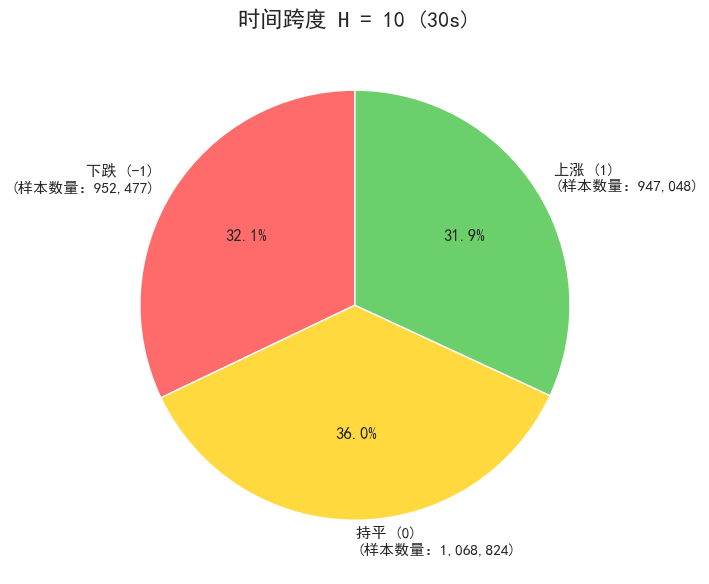


Label_mean 各类别数量:
  下跌 (-1): 952,477 (32.1%)
  持平 (0): 1,068,824 (36.0%)
  上涨 (1): 947,048 (31.9%)


In [32]:
# 统计标签分布并绘制饼图
try:
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

fig, ax = plt.subplots(figsize=(8, 6))

# Label_mean 分布 (基于未来平均价格)
label_mean_counts = df['Label_mean'].value_counts().sort_index()
labels_mean = ['下跌 (-1)', '持平 (0)', '上涨 (1)']
colors_mean = ['#ff6b6b', '#ffd93d', '#6bcf6b']

# 在标签中加入样本数量
labels_with_counts = [f'{label}\n(样本数量：{count:,})' for label, count in zip(labels_mean, label_mean_counts)]
ax.set_title('时间跨度 H = 10 (30s)', fontsize=16)
ax.pie(label_mean_counts, labels=labels_with_counts, autopct='%1.1f%%', colors=colors_mean, startangle=90)
plt.tight_layout()
plt.show()
fig.savefig('H10.png', dpi=300)

print("\nLabel_mean 各类别数量:")
for idx, count in label_mean_counts.items():
    label_name = {-1: '下跌', 0: '持平', 1: '上涨'}[idx]
    print(f"  {label_name} ({idx}): {count:,} ({count/len(df)*100:.1f}%)")

## 划分训练集和测试集

In [160]:
def split(df, ratio=0.8, label_col='Label_MidPrice'):
    """
    按时间顺序划分训练集和测试集
    标签映射: -1 -> 0, 0 -> 1, 1 -> 2 (XGBoost要求标签从0开始)
    """

    df = df.sort_values('datetime').reset_index(drop=True)
    split_idx = int(len(df) * ratio) # 切分点
    
    train_df = df.iloc[:split_idx].copy() # 训练集
    test_df = df.iloc[split_idx:].copy() # 测试集
    
    X_train = train_df[feature_cols]
    y_train = train_df[label_col] + 1  # 映射: -1->0, 0->1, 1->2
    
    X_test = test_df[feature_cols]
    y_test = test_df[label_col] + 1  # 映射: -1->0, 0->1, 1->2
    
    # 保留测试集的 real_target_return 用于回测
    test_returns = test_df['real_target_return'].reset_index(drop=True) if 'real_target_return' in test_df.columns else None
    
    print(f"使用标签: {label_col}")
    print(f"标签映射: -1->0(下跌), 0->1(持平), 1->2(上涨)")
    print(f"训练集: {len(X_train)}, 测试集: {len(X_test)}")
    print(f"训练集标签分布: {dict(y_train.value_counts().sort_index())}")
    print(f"测试集标签分布: {dict(y_test.value_counts().sort_index())}")
    
    if test_returns is not None:
        print(f"测试集 target_return 已保留，用于回测")

    return X_train, y_train, X_test, y_test, test_returns

In [177]:
# 选择预测标签：'Label_mean' 或 'Label_diff'
LABEL_COL = 'Label_mean'
LABEL_NAMES = ['下跌(0)', '持平(1)', '上涨(2)']
X_train, y_train, X_test, y_test, test_returns = split(df, ratio=0.8, label_col=LABEL_COL)

使用标签: Label_mean
标签映射: -1->0(下跌), 0->1(持平), 1->2(上涨)
训练集: 2324483, 测试集: 581121
训练集标签分布: {0: 757990, 1: 810725, 2: 755768}
测试集标签分布: {0: 178638, 1: 225663, 2: 176820}
测试集 target_return 已保留，用于回测


- standardization: 标准化

In [162]:
def standardization(X_train, X_test):
    """
    标准化
    """
    scaler = StandardScaler()
    
    # 仅在训练集上 fit
    scaler.fit(X_train)
    _X_train = scaler.transform(X_train)
    _X_test = scaler.transform(X_test)

    X_train = pd.DataFrame(_X_train, index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(_X_test , index=X_test.index, columns=X_test.columns)
    
    return X_train, X_test

In [180]:
X_train,X_test = standardization(X_train, X_test) # 标准化

## 特征筛选

- 最初构建的特征并不都是必要的，其中包含了许多冗余的特征，先使用 LightGBM 分类器筛选出最重要的 50 个特征，之后使用筛选后的特征拟合分类模型。

In [181]:
def select_features(X_train, y_train, top_k=50):
    """
    使用 LightGBM 分类器筛选最重要的 top_k 个特征
    """

    model = lgb.LGBMClassifier(
        n_estimators=600,
        learning_rate=0.015,
        num_leaves=63,
        min_child_samples=150,
        colsample_bytree=0.8,
        max_depth=8,
        min_split_gain=1.0,
        reg_alpha=50.0,
        reg_lambda=50.0, 
        subsample=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    # 获取特征重要性
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # 画图
    plt.figure(figsize=(20, 12))
    sns.barplot(data=importance.head(50), x='importance', y='feature')
    plt.show()
    
    selected_cols = importance.head(top_k)['feature'].tolist()
    return selected_cols, importance

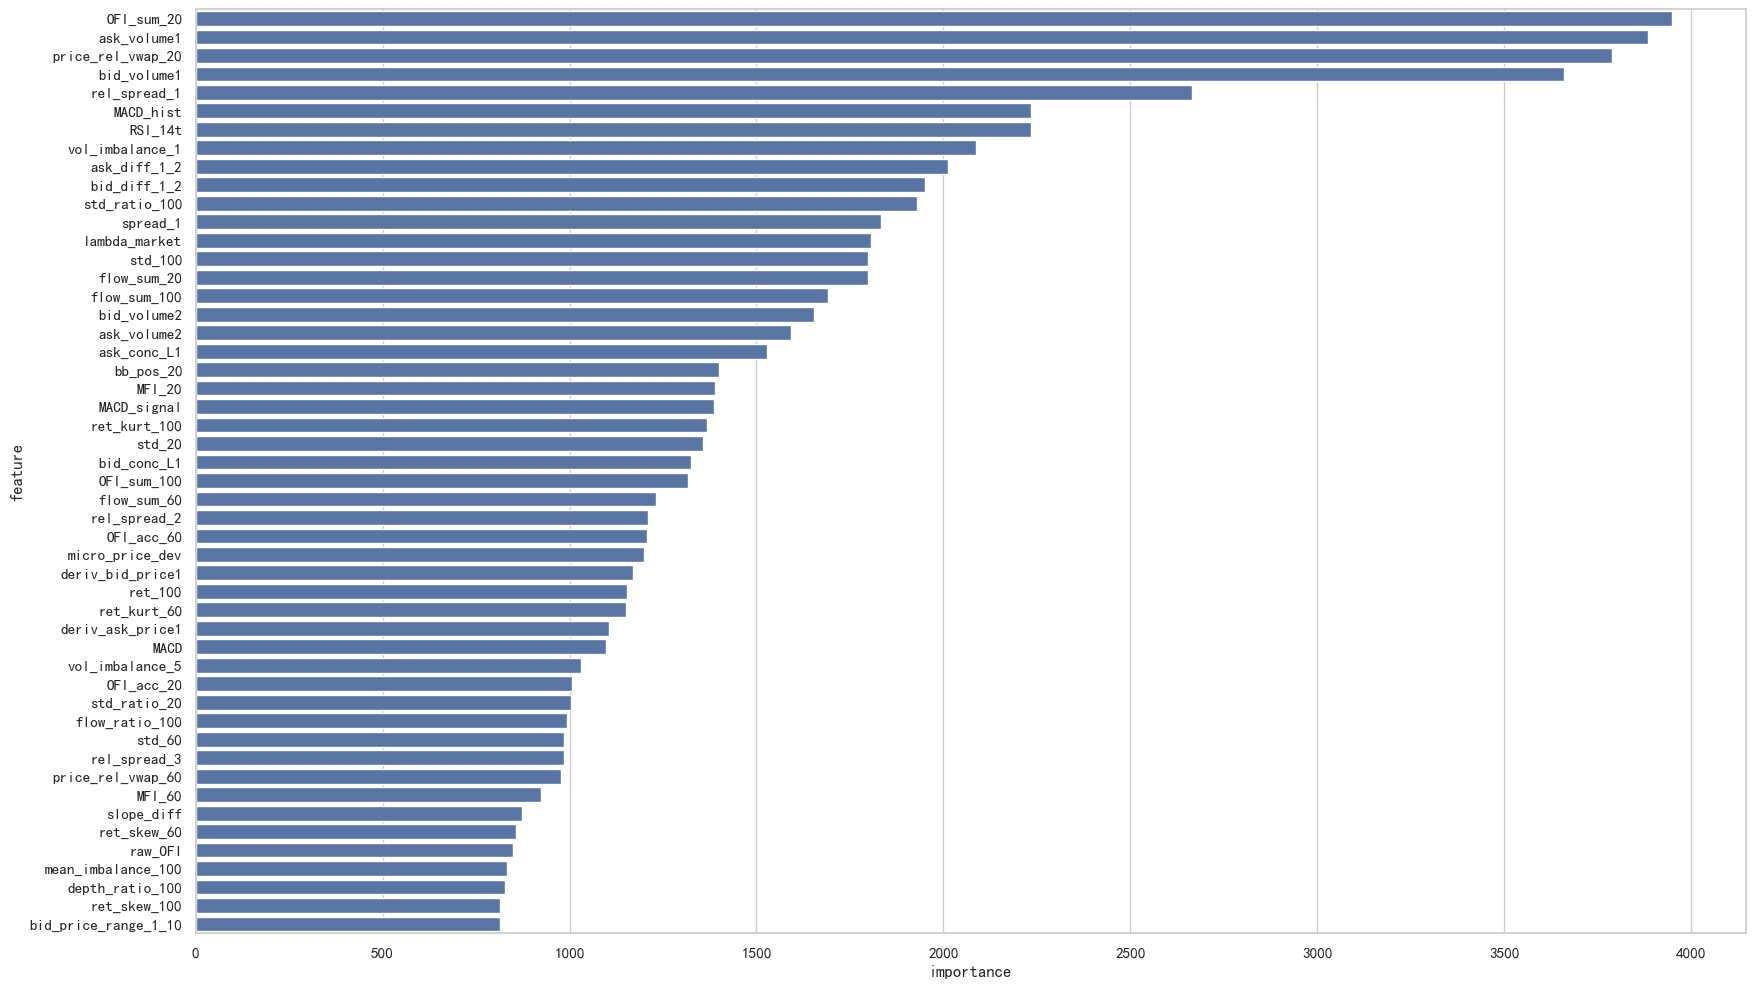

In [182]:
top_features, importance = select_features(X_train, y_train, top_k=50)

In [20]:
print(top_features)

['OFI_sum_20', 'ask_volume1', 'price_rel_vwap_20', 'bid_volume1', 'rel_spread_1', 'MACD_hist', 'RSI_14t', 'vol_imbalance_1', 'ask_diff_1_2', 'bid_diff_1_2', 'std_ratio_100', 'spread_1', 'lambda_market', 'std_100', 'flow_sum_20', 'flow_sum_100', 'bid_volume2', 'ask_volume2', 'ask_conc_L1', 'bb_pos_20', 'MFI_20', 'MACD_signal', 'ret_kurt_100', 'std_20', 'bid_conc_L1', 'OFI_sum_100', 'flow_sum_60', 'rel_spread_2', 'OFI_acc_60', 'micro_price_dev', 'deriv_bid_price1', 'ret_100', 'ret_kurt_60', 'deriv_ask_price1', 'MACD', 'vol_imbalance_5', 'OFI_acc_20', 'std_ratio_20', 'flow_ratio_100', 'std_60', 'rel_spread_3', 'price_rel_vwap_60', 'MFI_60', 'slope_diff', 'ret_skew_60', 'raw_OFI', 'mean_imbalance_100', 'depth_ratio_100', 'ret_skew_100', 'bid_price_range_1_10']


In [184]:
# 使用筛选后的特征运行
_X_train = X_train[top_features]
_X_test = X_test[top_features]

## 训练机器学习模型并预测

- ModelPipeline类：一个通用的pipeline，支持不同的机器学习模型/线性模型，增加代码的复用性。

In [55]:
class ModelPipeline:
    """
    通用模型训练 Pipeline，支持不同的分类模型
    """
    
    def __init__(self, model, name, use_early_stopping=False, early_stopping_rounds=100):
        """
        初始化 Pipeline
        use_early_stopping : 是否使用早停 (LightGBM, XGBoost 等支持)
        early_stopping_rounds : 早停轮数
        """
        self.model = model
        self.name = name
        self.use_early_stopping = use_early_stopping
        self.early_stopping_rounds = early_stopping_rounds
        self.is_fitted = False
    
    def _get_model_type(self):
        """
        判断模型类型（LightGBM和XGBoost支持早停）
        """
        model_str = str(type(self.model)).lower()
        if 'lgb' in model_str or 'lightgbm' in model_str:
            return 'lightgbm'
        elif 'xgb' in model_str or 'xgboost' in model_str:
            return 'xgboost'
        return 'sklearn'
        
    def fit(self, X_train, y_train, X_test=None, y_test=None):
        """
        训练模型，支持 LightGBM 和 XGBoost 的早停机制
        """
        model_type = self._get_model_type()
        
        if self.use_early_stopping and X_test is not None:
            if model_type == 'lightgbm':
                self.model.fit(
                    X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    eval_metric='multi_logloss',
                    callbacks=[lgb.early_stopping(self.early_stopping_rounds, verbose=False)]
                )
            elif model_type == 'xgboost':
                self.model.set_params(early_stopping_rounds=self.early_stopping_rounds)
                self.model.fit(
                    X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    verbose=False
                )
            else:
                self.model.fit(X_train, y_train)
        else:
            self.model.fit(X_train, y_train)
            
        self.is_fitted = True
        return self
    
    def predict(self, X):
        """预测"""
        if not self.is_fitted:
            raise ValueError("模型未训练，请先调用 fit 方法")
        return self.model.predict(X)
    
    def evaluate(self, y_true, y_pred):
        """评估模型，返回 F1 Score"""
        f1 = f1_score(y_true, y_pred, average='macro')
        return f1
    
    def run(self, X_train, y_train, X_test, y_test):
        """完整的训练-预测-评估流程"""
               
        self.fit(X_train, y_train, X_test=X_test, y_test=y_test)
        
        # 训练集预测
        y_train_pred = self.predict(X_train)
        # 测试集预测
        y_test_pred = self.predict(X_test)
        
        # 获取预测概率（用于AUC计算）
        y_train_proba = None
        y_test_proba = None
        if hasattr(self.model, 'predict_proba'):
            y_train_proba = self.model.predict_proba(X_train)
            y_test_proba = self.model.predict_proba(X_test)
        
        # 获取类别列表
        classes = np.unique(y_train)
        n_classes = len(classes)
        
        # 训练集指标（用于检查是否欠拟合/过拟合）
        train_accuracy = accuracy_score(y_train, y_train_pred)
        train_recall_macro = recall_score(y_train, y_train_pred, average='macro')
        train_recall_weighted = recall_score(y_train, y_train_pred, average='weighted')
        train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
        train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
         
        # 测试集指标
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_recall_macro = recall_score(y_test, y_test_pred, average='macro')
        test_recall_weighted = recall_score(y_test, y_test_pred, average='weighted')
        test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
        test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
        
        # 测试集 AUC
        test_auc = None
        if y_test_proba is not None:
            try:
                if n_classes == 2:
                    test_auc = roc_auc_score(y_test, y_test_proba[:, 1])
                else:
                    test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
            except:
                test_auc = None
        
        print(f"模型: {self.name}")
        print(f"\n【训练集指标】")
        print(f"  准确率 (Accuracy): {train_accuracy:.4f}")
        print(f"  召回率 (Recall macro): {train_recall_macro:.4f}")
        print(f"  召回率 (Recall weighted): {train_recall_weighted:.4f}")
        print(f"  F1 (macro): {train_f1_macro:.4f}")
        print(f"  F1 (weighted): {train_f1_weighted:.4f}")
        
        print(f"\n【测试集指标】")
        print(f"  准确率 (Accuracy): {test_accuracy:.4f}")
        print(f"  召回率 (Recall macro): {test_recall_macro:.4f}")
        print(f"  召回率 (Recall weighted): {test_recall_weighted:.4f}")
        print(f"  F1 (macro): {test_f1_macro:.4f}")
        print(f"  F1 (weighted): {test_f1_weighted:.4f}")
        
        # 对于 LinearSVC，使用 decision_function 计算 AUC
        if self.name == "SVC" and hasattr(self.model, 'decision_function'):
            try:
                y_scores = self.model.decision_function(X_test)
                # 将决策分数转换为伪概率 
                from scipy.special import softmax
                y_test_proba = softmax(y_scores, axis=1)
                test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
            except Exception as e:
                print(f" SVC AUC 计算失败: {e}")
                test_auc = None
        
        if test_auc is not None:
            print(f"  AUC: {test_auc:.4f}")
        
        return {
            'model_name': self.name,
            'pipeline': self,  # 保存完整的 pipeline 对象
            'model': self.model,  # 训练好的模型
            # 训练集指标
            'train_accuracy': train_accuracy,
            'train_recall_macro': train_recall_macro,
            'train_recall_weighted': train_recall_weighted,
            'train_f1_macro': train_f1_macro,
            'train_f1_weighted': train_f1_weighted,
            'train_predictions': y_train_pred,
            # 测试集指标
            'test_accuracy': test_accuracy,
            'test_recall_macro': test_recall_macro,
            'test_recall_weighted': test_recall_weighted,
            'test_f1_macro': test_f1_macro,
            'test_f1_weighted': test_f1_weighted,
            'test_auc': test_auc,
            'test_predictions': y_test_pred,
            'predictions': y_test_pred,  
            'test_proba': y_test_proba,
        }
    
    def plot_roc(self, y_true, y_proba, title_suffix=''):
        """绘制 ROC 曲线"""
        
        if y_proba is None:
            print("该模型不支持概率预测，无法绘制 ROC 曲线")
            return
        
        classes = np.unique(y_true) # 类别
        n_classes = len(classes)
        
        plt.figure(figsize=(10, 8))
        
        # 对每个类别绘制 ROC 曲线
        y_true_bin = label_binarize(y_true, classes=classes)
        colors = ['#2ecc71', '#95a5a6', '#e74c3c']
        linestyles = ['-', '--', '-.']
        
        for i, (cls, color) in enumerate(zip(classes, colors)):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            label_name = LABEL_NAMES[i] if i < len(LABEL_NAMES) else f'Class {cls}'
            plt.plot(fpr, tpr, color=color, linestyle=linestyles[i], lw=2, 
                    label=f'{label_name} (AUC = {roc_auc:.4f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='随机猜测')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('假阳性率 (FPR)')
        plt.ylabel('真阳性率 (TPR)')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot(self, y_true, y_pred):
        """绘制混淆矩阵"""
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=LABEL_NAMES,
                    yticklabels=LABEL_NAMES)
        plt.xlabel('预测')
        plt.ylabel('真实')
        plt.title(f'{self.name} 混淆矩阵')
        plt.show()

## 基于贝叶斯优化的自动调参寻找最优超参数（Optuna库）

In [23]:
class AutoTuner:
    """
    自动调参类，支持 Optuna 贝叶斯优化
    """
    
    def __init__(self, model_class, param_space, name='Model', n_trials=50, 
                 use_early_stopping=False, early_stopping_rounds=50):
        """
        初始化调参器
        model_class : 模型类 (如 lgb.LGBMClassifier, xgb.XGBClassifier, LogisticRegression)
        param_space : 参数搜索空间，格式为 {param_name: (type, low, high, [log])}, type: 'int', 'float', 'categorical'
        name : 模型名称
        n_trials : 调参试验次数
        use_early_stopping : 是否使用早停
        early_stopping_rounds : 早停轮数
        """
        self.model_class = model_class
        self.param_space = param_space
        self.name = name
        self.n_trials = n_trials
        self.use_early_stopping = use_early_stopping
        self.early_stopping_rounds = early_stopping_rounds
        self.best_params = None
        self.best_model = None
        self.study = None
    
    def _get_params(self, trial):
        """根据参数空间采样参数"""
        params = {}
        for param_name, config in self.param_space.items():
            param_type = config[0]
            if param_type == 'int':
                params[param_name] = trial.suggest_int(param_name, config[1], config[2])
            elif param_type == 'float':
                log = config[3] if len(config) > 3 else False
                params[param_name] = trial.suggest_float(param_name, config[1], config[2], log=log)
            elif param_type == 'categorical':
                params[param_name] = trial.suggest_categorical(param_name, config[1])
        return params
    
    def _get_model_type(self):
        """判断模型类型"""
        model_str = str(self.model_class).lower()
        if 'lgb' in model_str or 'lightgbm' in model_str:
            return 'lightgbm'
        elif 'xgb' in model_str or 'xgboost' in model_str:
            return 'xgboost'
        return 'sklearn'
        
    def _create_objective(self, X_train, y_train, X_val, y_val):
        """创建 Optuna 目标函数（优化 F1 Score）"""
        
        def objective(trial):
            # 参数
            params = self._get_params(trial)
            
            # 创建模型
            model = self.model_class(**params)
            
            # 训练模型
            model_type = self._get_model_type()
            if self.use_early_stopping and X_val is not None:
                if model_type == 'lightgbm':
                    model.fit(
                        X_train, y_train,
                        eval_set=[(X_val, y_val)],
                        eval_metric='multi_logloss',
                        callbacks=[lgb.early_stopping(self.early_stopping_rounds, verbose=False)]
                    )
                elif model_type == 'xgboost':
                    model.set_params(early_stopping_rounds=self.early_stopping_rounds)
                    model.fit(
                        X_train, y_train,
                        eval_set=[(X_val, y_val)],
                        verbose=False
                    )
                else:
                    model.fit(X_train, y_train)
            else:
                model.fit(X_train, y_train)
            
            # 使用 F1 Score (macro) 作为优化目标
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred, average='macro')
            return f1 if not np.isnan(f1) else 0.0
        
        return objective
    
    def tune(self, X_train, y_train, X_val, y_val, show_progress=True, sample_ratio=0.2):
        """
        执行自动调参
        sample_ratio : 用于调参的数据比例
        """
                
        # 对数据进行采样，只使用部分数据加速调参
        if sample_ratio < 1.0:
            n_samples = int(len(X_train) * sample_ratio)
            print(f"调参使用 {sample_ratio*100:.0f}% 数据 ({n_samples}/{len(X_train)} 样本)")
            
            # 分层采样保持类别比例
            _, X_train_sample, _, y_train_sample = train_test_split(
                X_train, y_train, 
                test_size=sample_ratio, 
                stratify=y_train, 
                random_state=42
            )
            _, X_val_sample, _, y_val_sample = train_test_split(
                X_val, y_val, 
                test_size=sample_ratio, 
                stratify=y_val, 
                random_state=42
            )
        else:
            X_train_sample, y_train_sample = X_train, y_train
            X_val_sample, y_val_sample = X_val, y_val
        
        objective = self._create_objective(X_train_sample, y_train_sample, X_val_sample, y_val_sample)
        
        self.study = optuna.create_study(direction='maximize')  # 最大化 F1 Score
        self.study.optimize(
            objective, 
            n_trials=self.n_trials, 
            show_progress_bar=show_progress
        )
        
        self.best_params = self.study.best_params
        print(f"\n{self.name} 最佳参数: {self.best_params}")
        print(f"{self.name} 最佳 F1 Score: {self.study.best_value:.4f}")
        
        return self.best_params
    
    def get_best_model(self):
        """根据最佳参数创建模型"""
        if self.best_params is None:
            raise ValueError("请先调用 tune() 方法进行调参")
        self.best_model = self.model_class(**self.best_params)
        return self.best_model
    
    def plot(self):
        """绘制优化历史"""
        if self.study is None:
            raise ValueError("请先调用 tune() 方法")
        
        try:
            sns.set_theme(style="whitegrid")
            plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
            plt.rcParams['axes.unicode_minus'] = False
        except:
            pass
        
        fig, axes = plt.subplots(1, 1, figsize=(7, 5))
        
        # 优化历史
        trials = self.study.trials
        values = [t.value for t in trials if t.value is not None]
        axes.plot(values, marker='o', markersize=3, alpha=0.7)
        axes.set_xlabel('Trial')
        axes.set_ylabel('F1 Score')
        axes.axhline(y=self.study.best_value, color='r', linestyle='--', 
                       label=f'Best: {self.study.best_value:.4f}')
        axes.legend()

In [27]:
# 定义分类模型的参数搜索空间
def get_lgb_param_space():
    """LightGBM 分类器参数搜索空间"""
    return {
        'n_estimators': ('int', 100, 600),
        'learning_rate': ('float', 0.01, 0.3, True),  # log scale
        'num_leaves': ('int', 15, 127),
        'max_depth': ('int', 3, 12),
        'min_child_samples': ('int', 10, 200),
        'subsample': ('float', 0.5, 1.0),
        'colsample_bytree': ('float', 0.5, 1.0),
        'reg_alpha': ('float', 1e-8, 10.0, True),
        'reg_lambda': ('float', 1e-8, 10.0, True),
    }

def get_xgb_param_space():
    """XGBoost 分类器参数搜索空间"""
    return {
        'n_estimators': ('int', 100, 600),
        'learning_rate': ('float', 0.01, 0.3, True),
        'max_depth': ('int', 3, 12),
        'min_child_weight': ('int', 1, 100),
        'subsample': ('float', 0.5, 1.0),
        'colsample_bytree': ('float', 0.5, 1.0),
        'reg_alpha': ('float', 1e-8, 10.0, True),
        'reg_lambda': ('float', 1e-8, 10.0, True),
    }

def get_logistic_param_space():
    """Logistic Regression 参数搜索空间"""
    return {
        'C': ('float', 1e-4, 10.0, True),
        'max_iter': ('int', 500, 2000)
    }

def get_svc_param_space():
    return {
        'C': ('float', 1e-3, 100.0, True),  
        'loss': ('categorical', ['hinge', 'squared_hinge'])
    }

def get_rf_param_space():
    """Random Forest 分类器参数搜索空间"""
    return {
        'n_estimators': ('int', 50, 300),
        'max_depth': ('int', 3, 15),
        'min_samples_split': ('int', 2, 50),
        'min_samples_leaf': ('int', 1, 30),
        'max_features': ('categorical', ['sqrt', 'log2', None]),
    }

In [28]:
def get_tuner_configs():
    """获取分类模型的调参器配置"""
    configs = {
        'LightGBM': {
            'model_class': lgb.LGBMClassifier,
            'param_space': get_lgb_param_space(),
            'use_early_stopping': True,
            'early_stopping_rounds': 50,
            'fixed_params': {'verbosity': -1, 
                             'random_state': 42, 
                             'n_jobs': -1, 
                             'class_weight': 'balanced',
                             'boosting_type': 'goss', # 基于梯度的单边采样,自动保留梯度大的样本，丢弃梯度小的样本
                             'max_bin': 63, # 直方图优化
                             }
        },
        'XGBoost': {
            'model_class': xgb.XGBClassifier,
            'param_space': get_xgb_param_space(),
            'use_early_stopping': True,
            'fixed_params': {'verbosity': 0, 
                             'random_state': 42, 
                             'n_jobs': -1, 
                             'use_label_encoder': False,
                             }
        },
        'LogisticRegression': {
            'model_class': LogisticRegression,
            'param_space': get_logistic_param_space(),
            'use_early_stopping': False,
            'early_stopping_rounds': 0,
            'fixed_params': {
                'random_state': 42,
                'class_weight': 'balanced',  
                'multi_class': 'ovr',       
                'solver': 'saga'        
}
        },
        'SVC': {
            'model_class': LinearSVC,
            'param_space': get_svc_param_space(),
            'use_early_stopping': False,
            'early_stopping_rounds': 0,
            'fixed_params': {'random_state': 42, 'class_weight': 'balanced'}
        },
        'RandomForest': {
            'model_class': RandomForestClassifier,
            'param_space': get_rf_param_space(),
            'use_early_stopping': False,
            'early_stopping_rounds': 0,
            'fixed_params': {'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}
        }
    }
    return configs

- auto_tune_and_run: 整合ModelPipeline类和AutoTuner类寻找最优参数并运行最优模型

In [29]:
def auto_tune_and_run(X_train, y_train, X_test, y_test, 
                      model_names=['LightGBM'], n_trials=30, configs=None, sample_ratio=0.2):
    """
    自动调参并运行分类模型
    sample_ratio :用于调参的数据比例
    """
    if configs is None:
        configs = get_tuner_configs()
    
    results = {}
    tuners = {}
    
    for name in model_names:
        if name not in configs:
            print(f"警告: 未找到 {name} 的配置，跳过")
            continue
            
        config = configs[name]
        print(f"正在调参: {name}")
        
        # 创建带固定参数的模型类
        fixed_params = config.get('fixed_params', {})
        class ModelWithFixedParams:
            def __init__(self, **kwargs):
                all_params = {**fixed_params, **kwargs}
                self.model = config['model_class'](**all_params)
            
            def fit(self, *args, **kwargs):
                return self.model.fit(*args, **kwargs)
            
            def predict(self, *args, **kwargs):
                return self.model.predict(*args, **kwargs)
            
            def set_params(self, **kwargs):
                return self.model.set_params(**kwargs)
        
        tuner = AutoTuner(
            model_class=lambda **kw: config['model_class'](**{**fixed_params, **kw}),
            param_space=config['param_space'],
            name=name,
            n_trials=n_trials,
            use_early_stopping=config.get('use_early_stopping', False),
            early_stopping_rounds=config.get('early_stopping_rounds', 50)
        )
        tuner.tune(X_train, y_train, X_test, y_test, sample_ratio=sample_ratio)
        
        # 获取最佳模型并评估（使用全部数据训练）
        print(f"\n使用全部数据训练最终模型...")
        best_params = {**fixed_params, **tuner.best_params}
        best_model = config['model_class'](**best_params)
        
        pipeline = ModelPipeline(
            model=best_model,
            name=f"{name}_Tuned",
            use_early_stopping=config.get('use_early_stopping', False),
            early_stopping_rounds=config.get('early_stopping_rounds', 50)
        )
        
        result = pipeline.run(X_train, y_train, X_test, y_test)
        result['best_params'] = best_params
        result['tuner'] = tuner
        result['config'] = config
        
        results[name] = result
        tuners[name] = tuner
    
    # 打印所有模型的汇总比较
    print("所有模型汇总比较")
    print(f"{'模型名称':<20} {'训练Acc':>10} {'测试Acc':>10} {'测试F1':>10} {'测试AUC':>10}")
    for name, res in results.items():
        train_acc = res.get('train_accuracy', 0)
        test_acc = res.get('test_accuracy', 0)
        test_f1 = res.get('test_f1_macro', 0)
        test_auc = res.get('test_auc', None)
        auc_str = f"{test_auc:.4f}" if test_auc is not None else "N/A"
        print(f"{name:<20} {train_acc:>10.4f} {test_acc:>10.4f} {test_f1:>10.4f} {auc_str:>10}")
    return results, tuners    

#### 对需要使用的模型进行调参，由于自动调参耗时较长这里先注释掉了

In [ ]:
# tuned_results1, tuners1 = auto_tune_and_run(
#     _X_train, y_train, _X_test, y_test,
#     model_names=['XGBoost'],  
#     n_trials=30,
#     sample_ratio=0.1
# )

In [32]:
# tuned_results2, tuners2 = auto_tune_and_run(
#     _X_train, y_train, _X_test, y_test,
#     model_names=['SVC','RandomForest'],  
#     n_trials=10,
#     sample_ratio=0.05
# )

正在调参: SVC
调参使用 5% 数据 (116224/2324483 样本)


  0%|          | 0/10 [00:00<?, ?it/s]


SVC 最佳参数: {'C': 0.003940045957700354, 'loss': 'squared_hinge'}
SVC 最佳 F1 Score: 0.5165

使用全部数据训练最终模型...
模型: SVC_Tuned

【训练集指标】
  准确率 (Accuracy): 0.5138
  召回率 (Recall macro): 0.5164
  召回率 (Recall weighted): 0.5138
  F1 (macro): 0.5117
  F1 (weighted): 0.5105

【测试集指标】
  准确率 (Accuracy): 0.5212
  召回率 (Recall macro): 0.5273
  召回率 (Recall weighted): 0.5212
  F1 (macro): 0.5215
  F1 (weighted): 0.5203
正在调参: RandomForest
调参使用 5% 数据 (116224/2324483 样本)


  0%|          | 0/10 [00:00<?, ?it/s]


RandomForest 最佳参数: {'n_estimators': 126, 'max_depth': 14, 'min_samples_split': 38, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
RandomForest 最佳 F1 Score: 0.5308

使用全部数据训练最终模型...
模型: RandomForest_Tuned

【训练集指标】
  准确率 (Accuracy): 0.5815
  召回率 (Recall macro): 0.5831
  召回率 (Recall weighted): 0.5815
  F1 (macro): 0.5811
  F1 (weighted): 0.5805

【测试集指标】
  准确率 (Accuracy): 0.5368
  召回率 (Recall macro): 0.5359
  召回率 (Recall weighted): 0.5368
  F1 (macro): 0.5351
  F1 (weighted): 0.5369
  AUC: 0.7243
所有模型汇总比较
模型名称                      训练Acc      测试Acc       测试F1      测试AUC
SVC                      0.5138     0.5212     0.5215        N/A
RandomForest             0.5815     0.5368     0.5351     0.7243


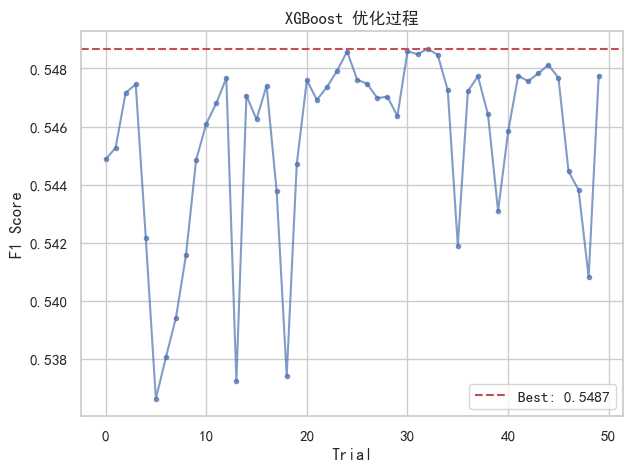

In [33]:
# 绘制优化过程
# for name, tuner in {**tuners1, **tuners2}.items():
#     print(f"\n{name} 优化过程:")
#     tuner.plot()
#     plt.show()

## 用最优参数训练模型并进行预测
- 在找到最优参数后，使用最优参数训练逻辑斯蒂回归、支持向量机(LinearSVC)、LightGBM和XGBoost模型

In [185]:
def get_models():
    """获取最优模型配置"""
    models = {
        'LogisticRegression': {
            'model': LogisticRegression(C = 0.000116, 
                                        max_iter=1200,
                                        class_weight='balanced',
                                        random_state=42,
                                        multi_class='ovr',
                                        solver='saga'),
            'use_early_stopping': False
        },
        'SVC': {
            'model': LinearSVC(
                C=0.004,
                loss='squared_hinge',
                class_weight='balanced',
                random_state=42
            )
        },
        'LightGBM': {
            'model': lgb.LGBMClassifier(
                n_estimators=526,
                learning_rate=0.023552,
                num_leaves=79,
                min_child_samples=189,
                colsample_bytree=0.61,
                max_depth=12,
                reg_alpha=0.0,
                reg_lambda=0.3, 
                subsample=0.5,
                random_state=42,
                n_jobs=-1,
                verbosity=-1,
                class_weight='balanced'
            ),
            'use_early_stopping': True,
            'early_stopping_rounds': 100
        },
        'XGBoost': {
            'model': xgb.XGBClassifier(
                n_estimators=512,
                learning_rate=0.031,
                max_depth=11,
                min_child_weight=54,
                subsample = 0.585,
                colsample_bytree=0.582,
                reg_alpha=0.000531,
                reg_lambda=0.021,
                random_state=42,
                n_jobs=-1,
                verbosity=0,
                use_label_encoder=False
            ),
            'use_early_stopping': True,
            'early_stopping_rounds': 100
        },
    
    }
    return models

In [186]:
def run(X_train, y_train, X_test, y_test, models=None):
    """运行所有模型并返回结果"""
    if models is None:
        models = get_models()
    
    results = {}
    
    for name, config in models.items():
        pipeline = ModelPipeline(
            model=config['model'],
            name=name,
            use_early_stopping=config.get('use_early_stopping', False),
            early_stopping_rounds=config.get('early_stopping_rounds', 100)
        )
        
        result = pipeline.run(X_train, y_train, X_test, y_test)
        results[name] = result
    
    return results

In [187]:
res = run(_X_train, y_train, _X_test, y_test)

模型: LogisticRegression

【训练集指标】
  准确率 (Accuracy): 0.5159
  召回率 (Recall macro): 0.5184
  召回率 (Recall weighted): 0.5159
  F1 (macro): 0.5141
  F1 (weighted): 0.5130

【测试集指标】
  准确率 (Accuracy): 0.5246
  召回率 (Recall macro): 0.5297
  召回率 (Recall weighted): 0.5246
  F1 (macro): 0.5249
  F1 (weighted): 0.5241
  AUC: 0.7098
模型: SVC

【训练集指标】
  准确率 (Accuracy): 0.5138
  召回率 (Recall macro): 0.5164
  召回率 (Recall weighted): 0.5138
  F1 (macro): 0.5117
  F1 (weighted): 0.5105

【测试集指标】
  准确率 (Accuracy): 0.5212
  召回率 (Recall macro): 0.5273
  召回率 (Recall weighted): 0.5212
  F1 (macro): 0.5215
  F1 (weighted): 0.5203
  AUC: 0.7110
模型: LightGBM

【训练集指标】
  准确率 (Accuracy): 0.5584
  召回率 (Recall macro): 0.5597
  召回率 (Recall weighted): 0.5584
  F1 (macro): 0.5582
  F1 (weighted): 0.5577

【测试集指标】
  准确率 (Accuracy): 0.5561
  召回率 (Recall macro): 0.5550
  召回率 (Recall weighted): 0.5561
  F1 (macro): 0.5543
  F1 (weighted): 0.5561
  AUC: 0.7429
模型: XGBoost

【训练集指标】
  准确率 (Accuracy): 0.6320
  召回率 (Recall macro): 0.6323

#### 集成模型(Ensemble)
- 这是 kaggle 数据竞赛中常用的技巧，将几个表现优异的模型预测结构加权，往往表现会超过单个模型
- 但是这种方法提升幅度往往不大，对于我们当前的场景并没有太大作用

In [196]:
def ensemble(res, model_names, weights=None):
   
    if weights is None:
        weights = [1.0] * len(model_names)
    
    # 归一化权重
    weights = np.array(weights) / np.sum(weights)
    
    # 获取训练集和测试集的概率预测
    train_probas = []
    test_probas = []
    
    for name in model_names:
        if name not in res:
            raise ValueError(f"模型 {name} 不在结果字典中")
        
        model_res = res[name]
        
        # 获取训练集概率
        if 'train_proba' in model_res and model_res['train_proba'] is not None:
            train_probas.append(model_res['train_proba'])
        
        # 获取测试集概率
        if 'test_proba' in model_res and model_res['test_proba'] is not None:
            test_probas.append(model_res['test_proba'])
        else:
            raise ValueError(f"模型 {name} 没有概率预测结果")
    
    # 加权平均测试集概率
    ensemble_test_proba = np.zeros_like(test_probas[0])
    for i, proba in enumerate(test_probas):
        ensemble_test_proba += weights[i] * proba
    
    # 从融合后的概率获取预测标签
    ensemble_test_pred = np.argmax(ensemble_test_proba, axis=1)
    
    # 加权平均训练集概率（如果所有模型都有训练集概率）
    ensemble_train_proba = None
    ensemble_train_pred = None
    if len(train_probas) == len(model_names):
        ensemble_train_proba = np.zeros_like(train_probas[0])
        for i, proba in enumerate(train_probas):
            ensemble_train_proba += weights[i] * proba
        ensemble_train_pred = np.argmax(ensemble_train_proba, axis=1)
    
    # 计算测试集指标
    test_accuracy = accuracy_score(y_test, ensemble_test_pred)
    test_recall_macro = recall_score(y_test, ensemble_test_pred, average='macro')
    test_recall_weighted = recall_score(y_test, ensemble_test_pred, average='weighted')
    test_f1_macro = f1_score(y_test, ensemble_test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, ensemble_test_pred, average='weighted')
    
    # 计算测试集AUC
    try:
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        test_auc = roc_auc_score(y_test_bin, ensemble_test_proba, average='macro', multi_class='ovr')
    except Exception as e:
        print(f"测试集AUC计算失败: {e}")
        test_auc = None
    
    # 计算训练集指标
    train_accuracy = None
    train_recall_macro = None
    train_recall_weighted = None
    train_f1_macro = None
    train_f1_weighted = None
    train_auc = None
    
    if ensemble_train_pred is not None:
        train_accuracy = accuracy_score(y_train, ensemble_train_pred)
        train_recall_macro = recall_score(y_train, ensemble_train_pred, average='macro')
        train_recall_weighted = recall_score(y_train, ensemble_train_pred, average='weighted')
        train_f1_macro = f1_score(y_train, ensemble_train_pred, average='macro')
        train_f1_weighted = f1_score(y_train, ensemble_train_pred, average='weighted')
        
        try:
            y_train_bin = label_binarize(y_train, classes=[0, 1, 2])
            train_auc = roc_auc_score(y_train_bin, ensemble_train_proba, average='macro', multi_class='ovr')
        except:
            train_auc = None

    ensemble_result = {
        # 训练集指标
        'train_accuracy': train_accuracy,
        'train_recall_macro': train_recall_macro,
        'train_recall_weighted': train_recall_weighted,
        'train_f1_macro': train_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'train_auc': train_auc,
        'train_predictions': ensemble_train_pred,
        'train_proba': ensemble_train_proba,
        # 测试集指标
        'test_accuracy': test_accuracy,
        'test_recall_macro': test_recall_macro,
        'test_recall_weighted': test_recall_weighted,
        'test_f1_macro': test_f1_macro,
        'test_f1_weighted': test_f1_weighted,
        'test_auc': test_auc,
        'test_predictions': ensemble_test_pred,
        'predictions': ensemble_test_pred,
        'test_proba': ensemble_test_proba,
        # 融合信息
        'model_names': model_names,
        'weights': weights.tolist(),
    }
    
    return ensemble_result


# 融合 XGBoost、LightGBM 和 LogisticRegression
ensemble_models = ['XGBoost', 'LightGBM', 'LogisticRegression']
ensemble_weights = [0.7, 0.25,0.05]  # XGBoost和LightGBM权重更高

ensemble_result = ensemble(res, ensemble_models, ensemble_weights)

# 添加到结果字典
res['Ensemble'] = ensemble_result

# 打印融合结果
print("="*70)
print("Ensemble 加权融合结果")
print(f"融合模型: {ensemble_models}")
print(f"权重: {[f'{w:.2f}' for w in ensemble_weights]}")
print("="*70)
print(f"\n【测试集指标】")
print(f"  准确率 (Accuracy): {ensemble_result['test_accuracy']:.4f}")
print(f"  召回率 (Recall macro): {ensemble_result['test_recall_macro']:.4f}")
print(f"  F1 (macro): {ensemble_result['test_f1_macro']:.4f}")
print(f"  F1 (weighted): {ensemble_result['test_f1_weighted']:.4f}")
if ensemble_result['test_auc']:
    print(f"  AUC: {ensemble_result['test_auc']:.4f}")

if ensemble_result['train_accuracy'] is not None:
    print(f"\n【训练集指标】")
    print(f"  准确率 (Accuracy): {ensemble_result['train_accuracy']:.4f}")
    print(f"  召回率 (Recall macro): {ensemble_result['train_recall_macro']:.4f}")
    print(f"  F1 (macro): {ensemble_result['train_f1_macro']:.4f}")
    if ensemble_result['train_auc']:
        print(f"  AUC: {ensemble_result['train_auc']:.4f}")

print("\n分类报告:")
print(classification_report(y_test, ensemble_result['predictions'], 
                            target_names=LABEL_NAMES))

# 与各单体模型对比
print("\n" + "="*70)
print("Ensemble vs 单体模型对比")
print("="*70)
print(f"{'模型':<20} | {'Test Accuracy':>14} | {'Test F1 macro':>14} | {'Test AUC':>10}")
print("-"*70)
for name in ensemble_models + ['Ensemble']:
    r = res[name]
    auc_str = f"{r['test_auc']:.4f}" if r.get('test_auc') else "N/A"
    print(f"{name:<20} | {r['test_accuracy']:>14.4f} | {r['test_f1_macro']:>14.4f} | {auc_str:>10}")
print("-"*70)

Ensemble 加权融合结果
融合模型: ['XGBoost', 'LightGBM', 'LogisticRegression']
权重: ['0.70', '0.25', '0.05']

【测试集指标】
  准确率 (Accuracy): 0.5573
  召回率 (Recall macro): 0.5551
  F1 (macro): 0.5549
  F1 (weighted): 0.5571
  AUC: 0.7442

分类报告:
              precision    recall  f1-score   support

       下跌(0)       0.55      0.52      0.53    178638
       持平(1)       0.58      0.58      0.58    225663
       上涨(2)       0.54      0.57      0.55    176820

    accuracy                           0.56    581121
   macro avg       0.56      0.56      0.55    581121
weighted avg       0.56      0.56      0.56    581121


Ensemble vs 单体模型对比
模型                   |  Test Accuracy |  Test F1 macro |   Test AUC
----------------------------------------------------------------------
XGBoost              |         0.5570 |         0.5544 |     0.7441
LightGBM             |         0.5561 |         0.5543 |     0.7429
LogisticRegression   |         0.5246 |         0.5249 |     0.7098
Ensemble             |        

In [198]:
# 汇总结果
del res['Ensemble']
print("所有模型详细指标对比")
print("="*90)
print(f"{'模型':<18} | {'数据集':<6} | {'Accuracy':>9} | {'Recall':>9} | {'F1':>9} | {'AUC':>9}")
print("-"*90)
for name, result in res.items():
    # 训练集
    train_auc_str = f"{result['train_auc']:.4f}" if result.get('train_auc') else "N/A"
    print(f"{name:<18} | {'训练集':<6} | {result['train_accuracy']:>9.4f} | {result['train_recall_macro']:>9.4f} | {result['train_f1_macro']:>9.4f} | {train_auc_str:>9}")
    # 测试集
    test_auc_str = f"{result['test_auc']:.4f}" if result.get('test_auc') else "N/A"
    print(f"{'':<18} | {'测试集':<6} | {result['test_accuracy']:>9.4f} | {result['test_recall_macro']:>9.4f} | {result['test_f1_macro']:>9.4f} | {test_auc_str:>9}")
    print("-"*90)
print("="*90)

所有模型详细指标对比
模型                 | 数据集    |  Accuracy |    Recall |        F1 |       AUC
------------------------------------------------------------------------------------------
LogisticRegression | 训练集    |    0.5159 |    0.5184 |    0.5141 |       N/A
                   | 测试集    |    0.5246 |    0.5297 |    0.5249 |    0.7098
------------------------------------------------------------------------------------------
SVC                | 训练集    |    0.5138 |    0.5164 |    0.5117 |       N/A
                   | 测试集    |    0.5212 |    0.5273 |    0.5215 |    0.7110
------------------------------------------------------------------------------------------
LightGBM           | 训练集    |    0.5584 |    0.5597 |    0.5582 |       N/A
                   | 测试集    |    0.5561 |    0.5550 |    0.5543 |    0.7429
------------------------------------------------------------------------------------------
XGBoost            | 训练集    |    0.6320 |    0.6323 |    0.6321 |       N/A
                 

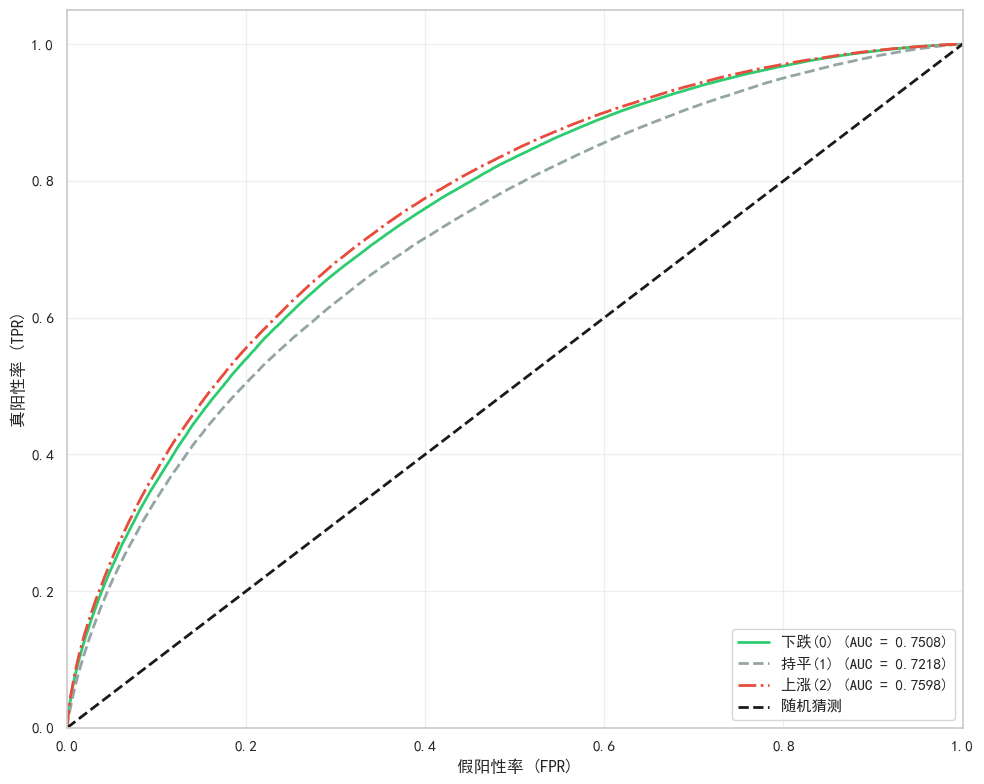

In [59]:
pipeline = res['XGBoost']['pipeline']
y_test_proba = res['XGBoost']['test_proba']
pipeline.plot_roc(y_test, y_test_proba)

最佳模型: XGBoost

最佳参数:

【测试集最终指标】
  准确率 (Accuracy): 0.5570
  召回率 (Recall macro): 0.5543
  F1 (macro): 0.5544
  F1 (weighted): 0.5567
  AUC: 0.7441

分类报告:
              precision    recall  f1-score   support

       下跌(0)       0.55      0.51      0.53    178638
       持平(1)       0.58      0.59      0.58    225663
       上涨(2)       0.54      0.56      0.55    176820

    accuracy                           0.56    581121
   macro avg       0.55      0.55      0.55    581121
weighted avg       0.56      0.56      0.56    581121



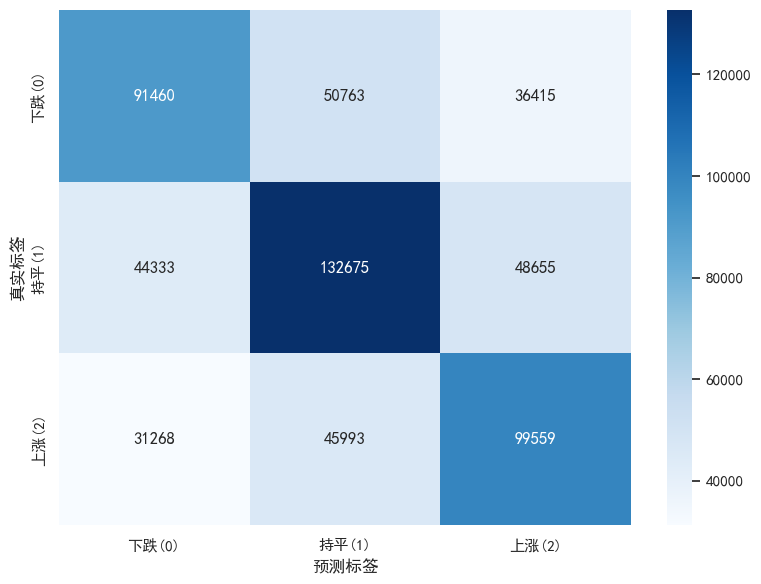

In [62]:
# 绘制最佳模型的混淆矩阵和分类报告
best_model_name = max(res, key=lambda k: res[k]['test_f1_macro'])
best_result = res[best_model_name]

print(f"最佳模型: {best_model_name}")
print(f"\n最佳参数:")
for k, v in best_result.get('best_params', {}).items():
    print(f"  {k}: {v}")

print(f"\n【测试集最终指标】")
print(f"  准确率 (Accuracy): {best_result['test_accuracy']:.4f}")
print(f"  召回率 (Recall macro): {best_result['test_recall_macro']:.4f}")
print(f"  F1 (macro): {best_result['test_f1_macro']:.4f}")
print(f"  F1 (weighted): {best_result['test_f1_weighted']:.4f}")
if best_result.get('test_auc'):
    print(f"  AUC: {best_result['test_auc']:.4f}")

print("\n分类报告:")
print(classification_report(y_test, best_result['predictions'], 
                            target_names=LABEL_NAMES))

# 绘制混淆矩阵
cm = confusion_matrix(y_test, best_result['predictions'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.tight_layout()
plt.show()

## 回测
- 对于表现最好的XGBoost模型，我们进行进一步的测试，模拟真实的股票交易逻辑，进行时间序列上的5折交叉验证。

In [148]:
class AdvancedEvaluator:
    def __init__(self, model, X, y, ask_prices, bid_prices, horizon=5, cost=0.0001):
        """
        ask_prices: 卖一价
        bid_prices: 买一价
        horizon: 持仓时间/Label 对应的预测周期
        cost: 单边手续费率 
        """
        self.model = model
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
        
        # 保存原始价格序列用于回测
        self.ask = ask_prices.reset_index(drop=True)
        self.bid = bid_prices.reset_index(drop=True)
        
        self.horizon = horizon
        self.cost = cost
 
        # 做多平仓价：未来的 Bid
        self.future_bid = self.bid.shift(-horizon).fillna(method='ffill')
        # 做空平仓价：未来的 Ask
        self.future_ask = self.ask.shift(-horizon).fillna(method='ffill')

        # 自动解析模型标签
        self.classes = self.model.classes_
        self.idx_down = np.where(self.classes == np.min(self.classes))[0][0]
        self.idx_up = np.where(self.classes == np.max(self.classes))[0][0]
        
        print(f"交易规则: 成本={cost*10000:.0f}bps, 持仓={horizon} ticks")
        print(f"做多逻辑: Ask买入 -> {horizon} ticks后 Bid卖出")
        print(f"做空逻辑: Bid卖出 -> {horizon} ticks后 Ask买回")
    
    @staticmethod
    def cooldown(signals, cooldown_ticks=5):
        """
        对原始信号应用冷却机制：
        开仓后，强制休息 cooldown_ticks 个时间步
        """
        n = len(signals)
        cooled_signals = np.zeros(n) # 初始化全 0
        
        # 记录上一次开仓的位置
        last_trade_idx = -cooldown_ticks - 1 
        
        for i in range(n):
            sig = signals[i]
            
            # 只有当有信号，且距离上次开仓超过了冷却期
            if sig != 0:
                if (i - last_trade_idx) > cooldown_ticks:
                    cooled_signals[i] = sig # 接受这个信号
                    last_trade_idx = i      # 更新上次开仓时间
                else:
                    # 处于冷却期，忽略该信号
                    cooled_signals[i] = 0
            else:
                cooled_signals[i] = 0
                
        return cooled_signals
    
    def pnl(self, signals, current_ask, current_bid, future_ask, future_bid):
        """
        计算考虑了盘口价差和手续费的真实盈亏
        """
        pnl = np.zeros_like(signals, dtype=float)
        
        # 做多
        # 收益 = (卖出价 / 买入价) - 1
        long_mask = (signals == 1)
        if np.any(long_mask):
            pnl[long_mask] = (future_bid[long_mask] / current_ask[long_mask]) - 1
            
        # 做空 
        # 收益 = 1 - (买回价 / 卖出价)
        short_mask = (signals == -1)
        if np.any(short_mask):
            pnl[short_mask] = 1 - (future_ask[short_mask] / current_bid[short_mask])
            
        # 扣除手续费
        # 换手: 信号变化量 (0->1 是1单位, 1->-1 是2单位)
        turnover = np.abs(np.diff(signals, prepend=0))
        net_pnl = pnl - (turnover * self.cost)
        
        # 处理最后几行可能因为 shift 产生的 NaN
        net_pnl = np.nan_to_num(net_pnl, nan=0.0)
        
        return net_pnl

    def run_ts(self, n_splits=5, gap=100, threshold=0.3):
        """
        执行时序交叉验证 (使用真实交易规则)
        """
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
        metrics = []
        
        print(f"\n开始 {n_splits} 折时序交叉验证...")
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(self.X)):
            X_val = self.X.iloc[val_idx]
            y_val = self.y.iloc[val_idx]
            
            # 获取验证集对应的价格切片
            ask_val = self.ask.iloc[val_idx].values
            bid_val = self.bid.iloc[val_idx].values
            f_ask_val = self.future_ask.iloc[val_idx].values
            f_bid_val = self.future_bid.iloc[val_idx].values
            
            # 预测
            preds_proba = self.model.predict_proba(X_val)
            score = preds_proba[:, self.idx_up] - preds_proba[:, self.idx_down]
            
            # 生成信号
            signals = np.zeros_like(score)
            signals[score > threshold] = 1
            signals[score < -threshold] = -1
            signals = AdvancedEvaluator.cooldown(signals, cooldown_ticks=10)
            spread = ask_val - bid_val
            spread_too_wide = spread > 0.011 # 稍微留点余量
            signals[spread_too_wide] = 0
            
            # 计算真实 PnL
            net_pnl = self.pnl(signals, ask_val, bid_val, f_ask_val, f_bid_val)
            cum_pnl = np.cumsum(net_pnl)
            
            # 统计指标
            # 准确率 (基于中间价的)
            acc = (self.model.predict(X_val) == y_val).mean()
            
            # 真实胜率 (扣费后盈利交易的比例)
            valid_trades = net_pnl[signals != 0]
            win_rate = np.mean(valid_trades > 0) if len(valid_trades) > 0 else 0
            
            fold_res = {
                'Fold': fold + 1,
                'Accuracy': acc,
                'Total_Return': cum_pnl[-1] if len(cum_pnl) > 0 else 0,
                'Win_Rate': win_rate,
                'Trade_Count': len(valid_trades)
            }
            metrics.append(fold_res)
            print(f"  Fold {fold+1}: Return={fold_res['Total_Return']:.4f}, WinRate={win_rate:.2%}, Trades={fold_res['Trade_Count']}")
            
        return pd.DataFrame(metrics)

    def full_backtest(self, threshold=0.3):
        """
        在全量数据上进行最终回测
        """
        preds_proba = self.model.predict_proba(self.X)
        score = preds_proba[:, self.idx_up] - preds_proba[:, self.idx_down]
        
        signals = np.zeros_like(score)
        signals[score > threshold] = 1
        signals[score < -threshold] = -1
        
        # 使用全量价格数据
        net_pnl = self.pnl(
            signals, 
            self.ask.values, 
            self.bid.values, 
            self.future_ask.values, 
            self.future_bid.values
        )
       
        equity = np.cumsum(net_pnl)
        
        # 画图
        plt.figure(figsize=(12, 6))
        plt.plot(equity, label='Bid/Ask', color='#2c3e50')
        plt.xlabel('Ticks')
        plt.ylabel('Cumulative Return')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        return equity, score

交易规则: 成本=1bps, 持仓=5 ticks
做多逻辑: Ask买入 -> 5 ticks后 Bid卖出
做空逻辑: Bid卖出 -> 5 ticks后 Ask买回

开始 5 折时序交叉验证...
  Fold 1: Return=0.0237, WinRate=48.40%, Trades=188
  Fold 2: Return=0.0206, WinRate=45.69%, Trades=197
  Fold 3: Return=0.0056, WinRate=45.65%, Trades=138
  Fold 4: Return=0.0337, WinRate=52.71%, Trades=203
  Fold 5: Return=0.0082, WinRate=41.90%, Trades=105

时序验证结果：
   Fold  Accuracy  Total_Return  Win_Rate  Trade_Count
0     1  0.546488      0.023672  0.484043          188
1     2  0.584257      0.020559  0.456853          197
2     3  0.578444      0.005571  0.456522          138
3     4  0.562306      0.033711  0.527094          203
4     5  0.547882      0.008164  0.419048          105


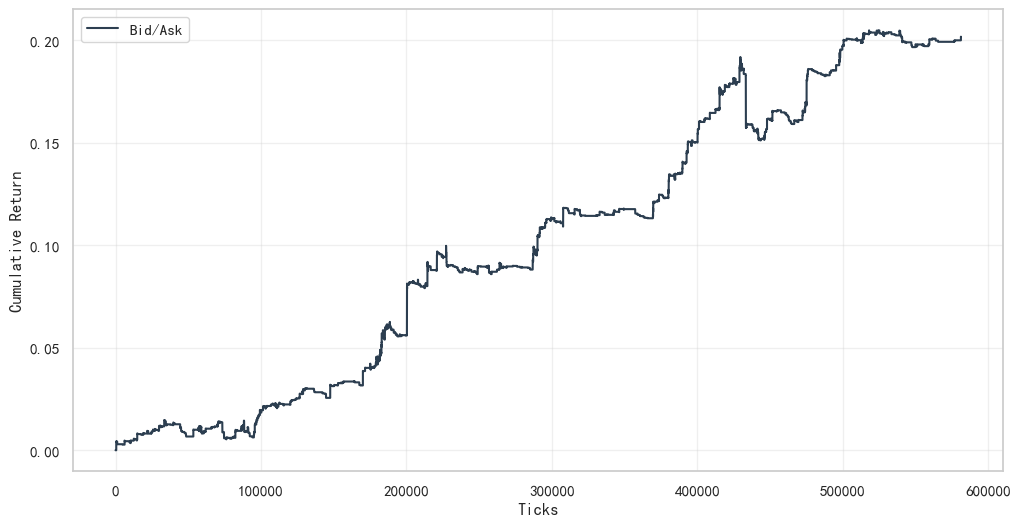

In [149]:
best_model_name = 'XGBoost' 
best_model = res[best_model_name]['model'] 
test_index = _X_test.index
ask_prices_test = df.loc[test_index, 'ask_price1']
bid_prices_test = df.loc[test_index, 'bid_price1']
evaluator = AdvancedEvaluator(
    model=best_model, 
    X=_X_test,               
    y=y_test, 
    ask_prices=ask_prices_test,
    bid_prices=bid_prices_test,
    horizon=5,     # 预测周期 
    cost=0.0001    # 万一手续费
)

# 执行时序交叉验证
cv_metrics = evaluator.run_ts(n_splits=5,gap=100,threshold=0.85)
print("\n时序验证结果：")
print(cv_metrics)


# 执行策略回测
equity_curve, signals = evaluator.full_backtest(threshold=0.85) 

- 从上面的实验中发现，盈亏与阈值有着较大的关系，因此特意进行了下面的测试

In [150]:
def run_sensitivity_test(evaluator, start=0.6, end=1.2, step=0.05):
    """
    遍历阈值，画出 收益 vs 交易次数 的关系图
    """
    thresholds = np.arange(start, end, step)
    results = []
    
    print(f"开始阈值敏感性测试 ({len(thresholds)} 个点)...")
    
    # 获取一次预测分 
    preds_proba = evaluator.model.predict_proba(evaluator.X)
    score = preds_proba[:, evaluator.idx_up] - preds_proba[:, evaluator.idx_down]
    
    # 遍历阈值
    for th in thresholds:
        # 生成信号
        signals = np.zeros_like(score)
        signals[score > th] = 1
        signals[score < -th] = -1
        signals = AdvancedEvaluator.cooldown(signals, cooldown_ticks=10)
        
        # 计算真实 PnL 
        net_pnl = evaluator.pnl(
            signals, 
            evaluator.ask.values, 
            evaluator.bid.values, 
            evaluator.future_ask.values, 
            evaluator.future_bid.values
        )
        
        total_ret = np.sum(net_pnl)
        trade_count = np.count_nonzero(signals)
        win_rate = np.mean(net_pnl[signals!=0] > 0) if trade_count > 0 else 0
        
        results.append({
            'Threshold': th,
            'Total Return': total_ret,
            'Trade Count': trade_count,
            'Win Rate': win_rate
        })
    
    df_res = pd.DataFrame(results)
    
 
    fig, ax1 = plt.subplots(figsize=(14, 8))
    color = '#e74c3c' # 红色
    ax1.set_xlabel('阈值', fontsize=12)
    ax1.set_ylabel('总收益', color=color, fontsize=12)
    ax1.plot(df_res['Threshold'], df_res['Total Return'], color=color, marker='o', linewidth=2, label='Total Return')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()  
    color = '#3498db' # 蓝色
    ax2.set_ylabel('交易次数', color=color, fontsize=12)
    ax2.plot(df_res['Threshold'], df_res['Trade Count'], color=color, linestyle='--', marker='x', label='Trade Count')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.tight_layout()
    plt.show()
    
    return df_res

开始阈值敏感性测试 (13 个点)...


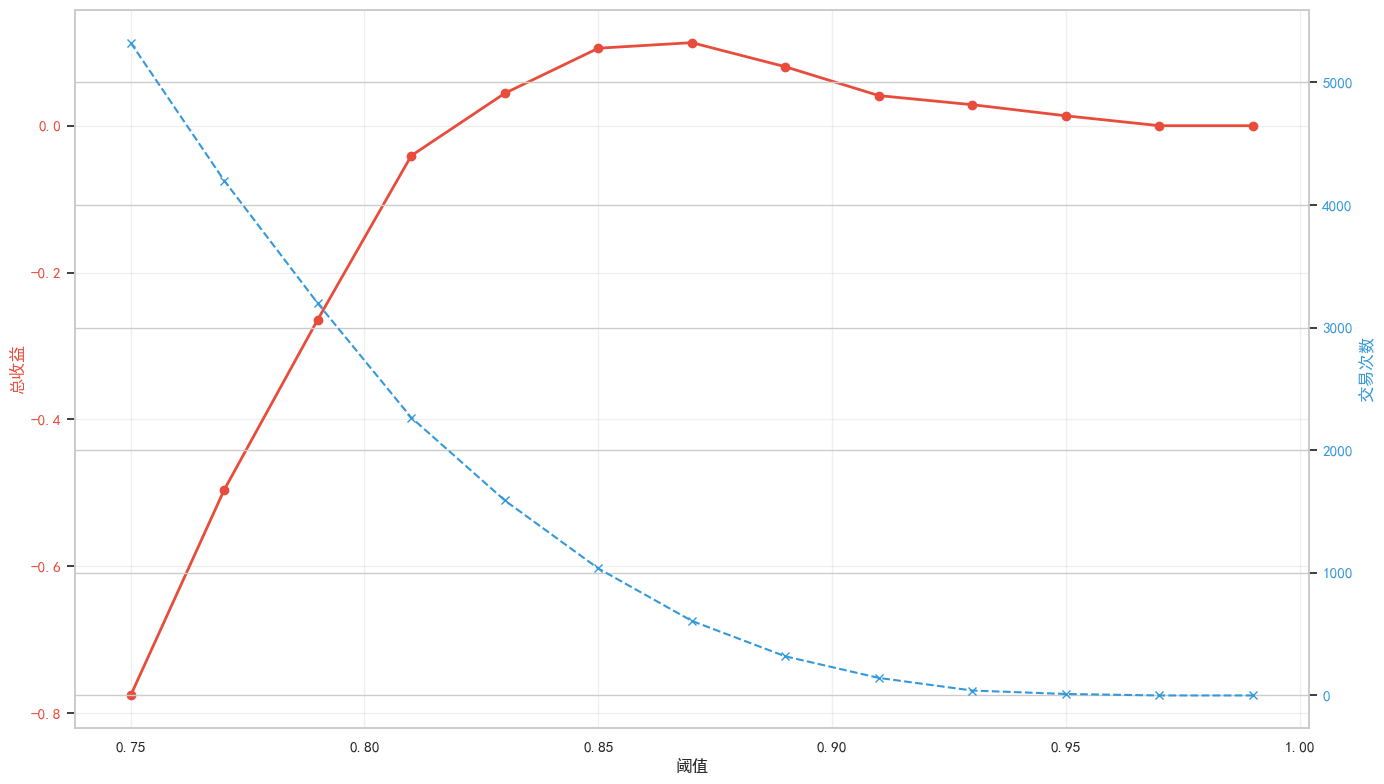

In [151]:
df_sensitivity = run_sensitivity_test(evaluator, start=0.75, end=1.0, step=0.02)